# Inspect the reprocessed QLP+TGLC (through-S103) light curves

QA for the FITS produced by `db_to_fits.py`. Confirms: schema matches the training FITS,
the curves stitch legacy-QLP (≤S93) + TGLC (≥S94), SAP_FLUX is relative flux (transits dip),
and the 3 aperture channels (SML/MID/LAG) are distinct.

Run with an env that has astropy + matplotlib + pandas (e.g. the QLP venv or your own):
`PYTHONPATH= /sw/qlp-environment/.venv/bin/python -m jupyter nbconvert --execute ...`,
or just open in Jupyter/VSCode.

In [2]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits

OUT   = '/pdo/users/pablomer/mnt/tess/reprocessed_s103_qlptglc_fits_files'
COMP  = 'data/reobserved_s103_companion.csv'
SUMM  = os.path.join(OUT, '_run_summary.csv')
OLDDIR = '/pdo/users/pablomer/mnt/tess/april2025_dataset_fits_files'  # existing QLP-only FITS

comp = pd.read_csv(COMP)
summ = pd.read_csv(SUMM)
print('companion TCEs:', len(comp), '| unique TICs:', comp['TIC ID'].nunique())
print('run summary status counts:')
print(summ['status'].value_counts())
summ.head()

companion TCEs: 5834 | unique TICs: 5781
run summary status counts:
status
written    5781
Name: count, dtype: int64


,tic,status,npts,n_tglc,bjd_min,bjd_max,cad_min,cad_max,msg
0,1449756,written,28958,24162,1437.993183,4045.899739,10105,1217565,NaN
1,1449640,written,28958,24162,1437.993153,4045.899710,10105,1217565,NaN
2,1528696,written,28961,24165,1437.993497,4045.900103,10105,1217565,NaN
3,592638,written,28961,24165,1437.993673,4045.899977,10105,1217565,NaN
4,1260235,written,12370,4560,1517.369271,4073.781019,13915,1229609,NaN


In [3]:
def fpath(tic, sector=103, outdir=OUT):
    return os.path.join(outdir, 'astronet_hlsp_qlptglc_tess_ffi-s%04d-%016d_tess_v01_llc.fits' % (sector, int(tic)))

def load(tic, sector=103, outdir=OUT):
    with fits.open(fpath(tic, sector, outdir)) as h:
        d = h[1].data
        out = {c.name: np.asarray(d[c.name]) for c in d.columns}
        out['_hdr'] = dict(h[0].header)
    return out

def tglc_mask(lc):
    """Boolean mask of TGLC-era (S94+) cadences, using NTGLCCAD from the header."""
    n = len(lc['CADENCENO']); ntglc = int(lc['_hdr'].get('NTGLCCAD', 0) or 0)
    if ntglc <= 0 or ntglc >= n:
        return np.zeros(n, bool) if ntglc <= 0 else np.ones(n, bool)
    thresh = np.sort(lc['CADENCENO'])[n - ntglc]
    return lc['CADENCENO'] >= thresh

# schema check on one file
ex = int(summ[summ.status=='written'].iloc[0]['tic'])
lc = load(ex)
print('example TIC', ex)
print('columns:', [k for k in lc if not k.startswith('_')])
print('SAP_FLUX median=%.4f min=%.4f  n=%d  NTGLCCAD=%s' % (
    np.nanmedian(lc['SAP_FLUX']), np.nanmin(lc['SAP_FLUX']), len(lc['TIME']), lc['_hdr'].get('NTGLCCAD')))

example TIC 1449756
columns: ['TIME', 'CADENCENO', 'SAP_FLUX', 'QUALITY', 'SAP_FLUX_SML', 'SAP_FLUX_MID', 'SAP_FLUX_LAG']
SAP_FLUX median=0.9995 min=0.0859  n=28958  NTGLCCAD=24162


In [4]:
# Pick one example per label (P/E/J) that actually has TGLC-era data
summ_ok = summ[summ.status=='written'].copy()
lab = comp.drop_duplicates('TIC ID').set_index('TIC ID')['first_letter']
summ_ok['label'] = summ_ok['tic'].map(lab)
picks = {}
for L in ['p','e','j']:
    cand = summ_ok[(summ_ok.label==L) & (summ_ok.n_tglc>0)].sort_values('n_tglc', ascending=False)
    if len(cand):
        picks[L] = int(cand.iloc[0]['tic'])
print('examples:', picks)

examples: {'p': 149302744, 'e': 33878688, 'j': 382145868}


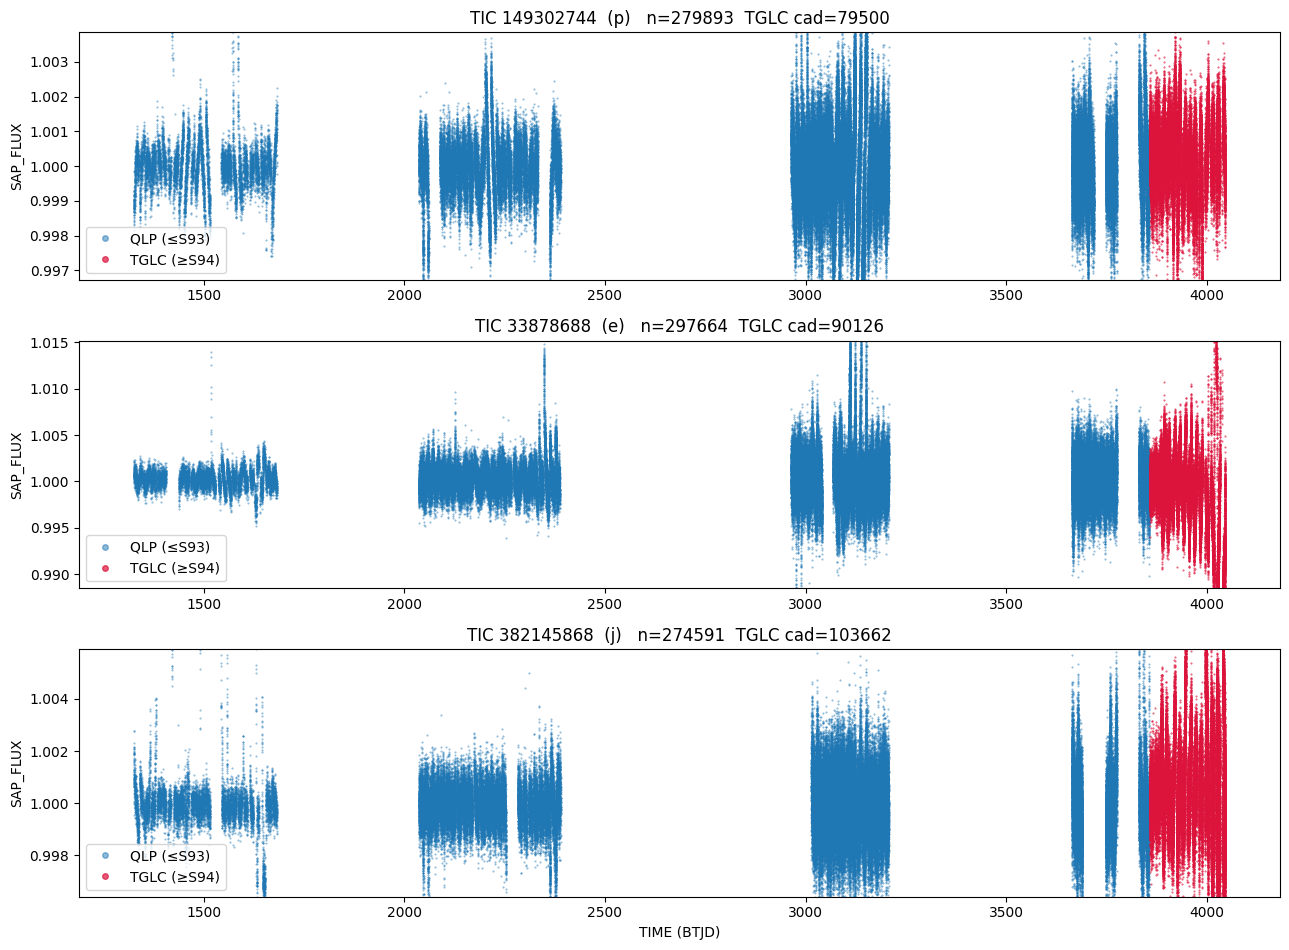

In [5]:
# Full stitched light curves, TGLC (S94+) portion highlighted
fig, axes = plt.subplots(len(picks), 1, figsize=(13, 3.2*len(picks)), squeeze=False)
for ax, (L, tic) in zip(axes[:,0], picks.items()):
    lc = load(tic); q = lc['QUALITY']==0; m = tglc_mask(lc)
    ax.plot(lc['TIME'][q&~m], lc['SAP_FLUX'][q&~m], '.', ms=1, alpha=.5, label='QLP (≤S93)')
    ax.plot(lc['TIME'][q&m],  lc['SAP_FLUX'][q&m],  '.', ms=1, alpha=.7, color='crimson', label='TGLC (≥S94)')
    ax.set_title('TIC %d  (%s)   n=%d  TGLC cad=%d' % (tic, L, len(lc['TIME']), int(lc['_hdr'].get('NTGLCCAD',0))))
    ax.set_ylabel('SAP_FLUX'); ax.set_ylim(np.nanpercentile(lc['SAP_FLUX'][q], [0.5, 99.5]))
    ax.legend(markerscale=8, loc='lower left')
axes[-1,0].set_xlabel('TIME (BTJD)')
plt.tight_layout(); plt.show()

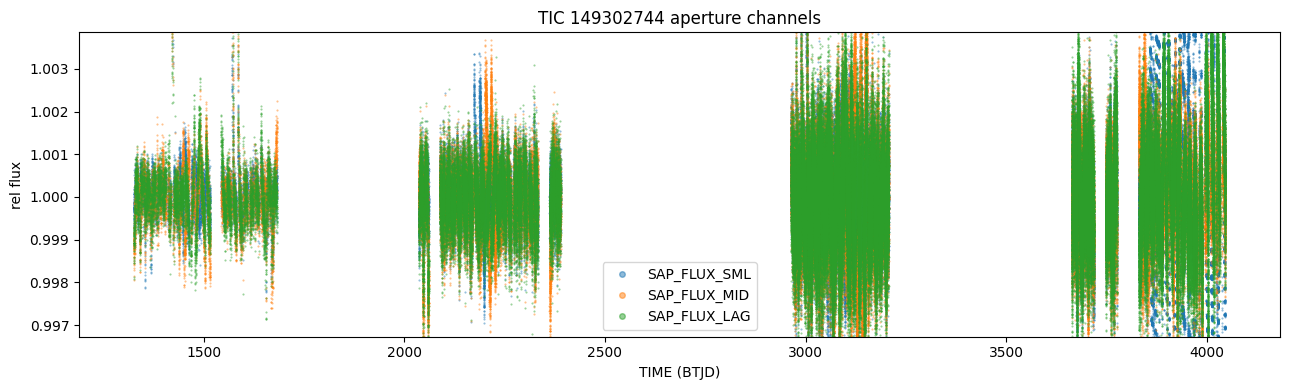

max per aperture: {'SAP_FLUX_SML': 1.034, 'SAP_FLUX_MID': 1.018, 'SAP_FLUX_LAG': 1.024}


In [6]:
# Aperture channels are distinct (SML=small, MID=primary=SAP_FLUX, LAG=large)
tic = picks.get('p') or list(picks.values())[0]
lc = load(tic); q = lc['QUALITY']==0
fig, ax = plt.subplots(figsize=(13,4))
for col, c in [('SAP_FLUX_SML','C0'),('SAP_FLUX_MID','C1'),('SAP_FLUX_LAG','C2')]:
    ax.plot(lc['TIME'][q], lc[col][q], '.', ms=1, alpha=.5, color=c, label=col)
ax.set_title('TIC %d aperture channels' % tic); ax.set_xlabel('TIME (BTJD)'); ax.set_ylabel('rel flux')
ax.set_ylim(np.nanpercentile(lc['SAP_FLUX'][q], [0.5, 99.5])); ax.legend(markerscale=8)
plt.tight_layout(); plt.show()
print('max per aperture:', {c: round(float(np.nanmax(lc[c][q])),3) for c in ['SAP_FLUX_SML','SAP_FLUX_MID','SAP_FLUX_LAG']})

p


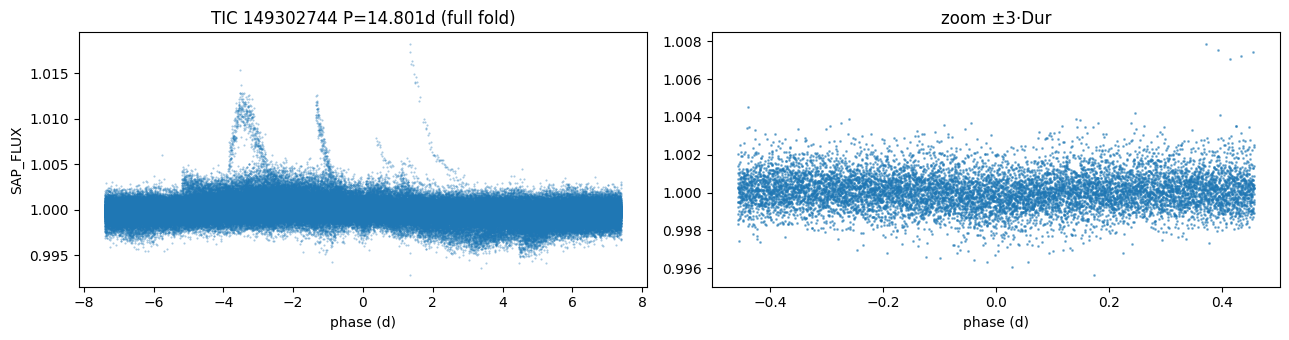

e


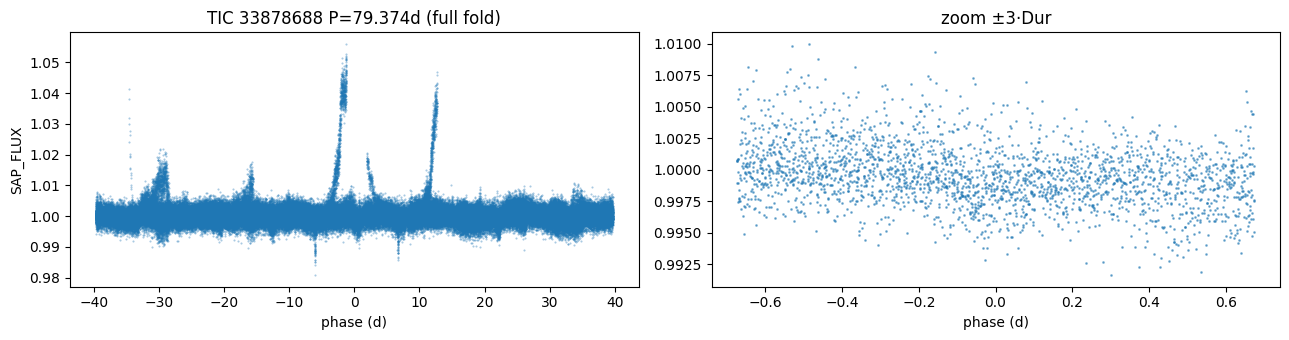

j


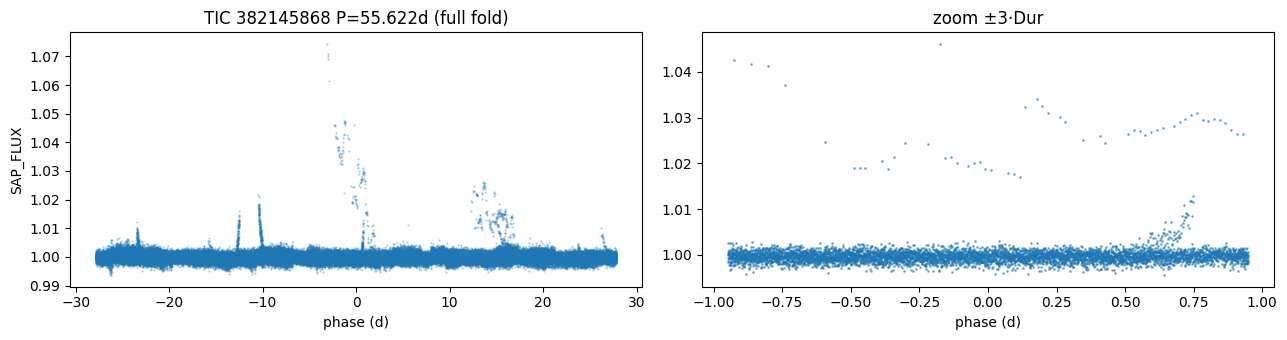

In [10]:
# Phase-fold on the TCE ephemeris (from the companion CSV) to see the transit
def phase_fold(tic):
    row = comp[comp['TIC ID']==tic].iloc[0]
    per, epo, dur = float(row['Per']), float(row['Epoc']), float(row['Dur'])
    lc = load(tic)
    q = (lc['QUALITY']==0) & np.isfinite(lc['SAP_FLUX'])
    m = tglc_mask(lc)          # rebuild for this lc
    t, f = lc['TIME'][q & ~m], lc['SAP_FLUX'][q & ~m]  # QLP only
    ph = ((t - epo + 0.5*per) % per) - 0.5*per
    fig, ax = plt.subplots(1,2, figsize=(13,3.5))
    ax[0].plot(ph, f, '.', ms=1, alpha=.4); ax[0].set_title('TIC %d P=%.3fd (full fold)'%(tic,per))
    ax[0].set_xlabel('phase (d)'); ax[0].set_ylabel('SAP_FLUX')
    w = 3*dur if np.isfinite(dur) and dur>0 else 0.2*per
    sel = np.abs(ph) < w
    ax[1].plot(ph[sel], f[sel], '.', ms=2, alpha=.5); ax[1].set_title('zoom ±3·Dur'); ax[1].set_xlabel('phase (d)')
    plt.tight_layout(); plt.show()

for L, tic in picks.items():
    print(L); phase_fold(tic)

In [8]:
# Cross-check: a QLP-only overlap target vs the existing april2025 FITS (same TIC)
# For the OLD file the sector tag differs; find whatever april2025 file exists for this TIC.
def old_path(tic):
    hits = glob.glob(os.path.join(OLDDIR, 'astronet_hlsp_qlp_tess_ffi-s*-%016d_tess_v01_llc.fits'%int(tic)))
    return hits[0] if hits else None

overlap = [int(t) for t in summ_ok['tic'] if old_path(int(t))][:1]
if overlap:
    tic = overlap[0]; new = load(tic)
    with fits.open(old_path(tic)) as h: old = {c.name: np.asarray(h[1].data[c.name]) for c in h[1].data.columns}
    fig, ax = plt.subplots(figsize=(13,4)); qn=new['QUALITY']==0; qo=old['QUALITY']==0
    ax.plot(old['TIME'][qo], old['SAP_FLUX'][qo]/np.nanmedian(old['SAP_FLUX'][qo]), '.', ms=1, alpha=.5, label='OLD april2025 (QLP)')
    ax.plot(new['TIME'][qn], new['SAP_FLUX'][qn], '.', ms=1, alpha=.5, label='NEW qlptglc (DB)')
    ax.set_title('TIC %d: NEW vs OLD (NEW extends into TGLC sectors)'%tic); ax.legend(markerscale=8)
    ax.set_xlabel('TIME (BTJD)'); ax.set_ylabel('rel flux'); plt.tight_layout(); plt.show()
    print('OLD span %.0f..%.0f (n=%d) | NEW span %.0f..%.0f (n=%d)' % (
        np.nanmin(old['TIME']), np.nanmax(old['TIME']), qo.sum(),
        np.nanmin(new['TIME']), np.nanmax(new['TIME']), qn.sum()))
else:
    print('no overlap TIC found in april2025 dir')

KeyboardInterrupt: 

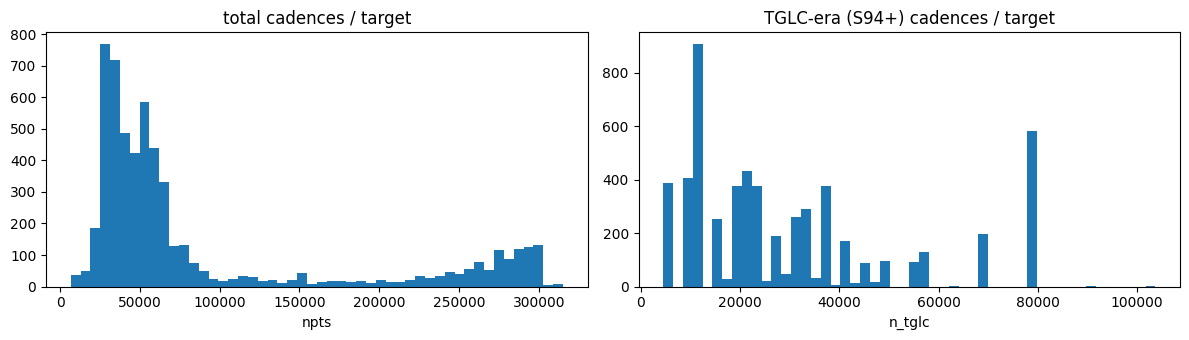

targets written: 5781
with TGLC cadences: 5781
non-written: {}


In [ ]:
# Run-wide sanity: distributions of #cadences and TGLC-era cadences
ok = summ[summ.status=='written']
fig, ax = plt.subplots(1,2, figsize=(12,3.5))
ax[0].hist(ok['npts'], bins=50); ax[0].set_title('total cadences / target'); ax[0].set_xlabel('npts')
ax[1].hist(ok['n_tglc'], bins=50); ax[1].set_title('TGLC-era (S94+) cadences / target'); ax[1].set_xlabel('n_tglc')
plt.tight_layout(); plt.show()
print('targets written:', len(ok))
print('with TGLC cadences:', int((ok['n_tglc']>0).sum()))
print('non-written:', dict(summ[summ.status!='written']['status'].value_counts()))